In [2]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from sklearn.ensemble import RandomForestClassifier
from scipy.stats import chi2_contingency
from sklearn.model_selection import train_test_split

In [3]:
os.getcwd()

'/home/ae7ba225-76ef-4005-aee2-7847a70630ed/SilentTelecomChurn'

In [4]:
df = pd.read_csv('/home/ae7ba225-76ef-4005-aee2-7847a70630ed/SilentTelecomChurn/CustomerChurn.csv')
df.head()

,LoyaltyID,Customer ID,Senior Citizen,Partner,Dependents,Tenure,Phone Service,Multiple Lines,Internet Service,Online Security,...,Device Protection,Tech Support,Streaming TV,Streaming Movies,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn
0,318537,7590-VHVEG,No,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,152148,5575-GNVDE,No,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,326527,3668-QPYBK,No,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,845894,7795-CFOCW,No,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,503388,9237-HQITU,No,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [5]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   LoyaltyID          7043 non-null   int64  
 1   Customer ID        7043 non-null   object 
 2   Senior Citizen     7043 non-null   object 
 3   Partner            7043 non-null   object 
 4   Dependents         7043 non-null   object 
 5   Tenure             7043 non-null   int64  
 6   Phone Service      7043 non-null   object 
 7   Multiple Lines     7043 non-null   object 
 8   Internet Service   7043 non-null   object 
 9   Online Security    7043 non-null   object 
 10  Online Backup      7043 non-null   object 
 11  Device Protection  7043 non-null   object 
 12  Tech Support       7043 non-null   object 
 13  Streaming TV       7043 non-null   object 
 14  Streaming Movies   7043 non-null   object 
 15  Contract           7043 non-null   object 
 16  Paperless Billing  7043 

,LoyaltyID,Tenure,Monthly Charges
count,7043.000000,7043.000000,7043.000000
mean,550382.651001,32.371149,64.761692
std,260776.118690,24.559481,30.090047
min,100346.000000,0.000000,18.250000
25%,323604.500000,9.000000,35.500000
50%,548704.000000,29.000000,70.350000
75%,776869.000000,55.000000,89.850000
max,999912.000000,72.000000,118.750000


In [6]:
df.isnull().sum()

LoyaltyID            0
Customer ID          0
Senior Citizen       0
Partner              0
Dependents           0
Tenure               0
Phone Service        0
Multiple Lines       0
Internet Service     0
Online Security      0
Online Backup        0
Device Protection    0
Tech Support         0
Streaming TV         0
Streaming Movies     0
Contract             0
Paperless Billing    0
Payment Method       0
Monthly Charges      0
Total Charges        0
Churn                0
dtype: int64

In [7]:
df["TotalCharges"] = pd.to_numeric(df["Total Charges"], errors="coerce")

In [8]:
df.isnull().sum()

LoyaltyID             0
Customer ID           0
Senior Citizen        0
Partner               0
Dependents            0
Tenure                0
Phone Service         0
Multiple Lines        0
Internet Service      0
Online Security       0
Online Backup         0
Device Protection     0
Tech Support          0
Streaming TV          0
Streaming Movies      0
Contract              0
Paperless Billing     0
Payment Method        0
Monthly Charges       0
Total Charges         0
Churn                 0
TotalCharges         11
dtype: int64

In [9]:
df = df.dropna()

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 7032 entries, 0 to 7042
Data columns (total 22 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   LoyaltyID          7032 non-null   int64  
 1   Customer ID        7032 non-null   object 
 2   Senior Citizen     7032 non-null   object 
 3   Partner            7032 non-null   object 
 4   Dependents         7032 non-null   object 
 5   Tenure             7032 non-null   int64  
 6   Phone Service      7032 non-null   object 
 7   Multiple Lines     7032 non-null   object 
 8   Internet Service   7032 non-null   object 
 9   Online Security    7032 non-null   object 
 10  Online Backup      7032 non-null   object 
 11  Device Protection  7032 non-null   object 
 12  Tech Support       7032 non-null   object 
 13  Streaming TV       7032 non-null   object 
 14  Streaming Movies   7032 non-null   object 
 15  Contract           7032 non-null   object 
 16  Paperless Billing  7032 

In [11]:
df.drop(columns=['TotalCharges'], inplace=True)

In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 7032 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   LoyaltyID          7032 non-null   int64  
 1   Customer ID        7032 non-null   object 
 2   Senior Citizen     7032 non-null   object 
 3   Partner            7032 non-null   object 
 4   Dependents         7032 non-null   object 
 5   Tenure             7032 non-null   int64  
 6   Phone Service      7032 non-null   object 
 7   Multiple Lines     7032 non-null   object 
 8   Internet Service   7032 non-null   object 
 9   Online Security    7032 non-null   object 
 10  Online Backup      7032 non-null   object 
 11  Device Protection  7032 non-null   object 
 12  Tech Support       7032 non-null   object 
 13  Streaming TV       7032 non-null   object 
 14  Streaming Movies   7032 non-null   object 
 15  Contract           7032 non-null   object 
 16  Paperless Billing  7032 

In [13]:
df = df.drop("Customer ID", axis=1)

In [14]:
# Convert Target Variable
df["Churn"] = df["Churn"].map({"Yes": 1, "No": 0})

In [14]:
df.head()

,LoyaltyID,Senior Citizen,Partner,Dependents,Tenure,Phone Service,Multiple Lines,Internet Service,Online Security,Online Backup,Device Protection,Tech Support,Streaming TV,Streaming Movies,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn
0,318537,No,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0
1,152148,No,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,0
2,326527,No,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1
3,845894,No,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,0
4,503388,No,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1


In [15]:
df_encoded = df.copy()

for col in df_encoded.columns:
    if df_encoded[col].dtype == "object":
        le = LabelEncoder()
        df_encoded[col] = le.fit_transform(df_encoded[col])

In [16]:
target = "Churn"
X = df_encoded.drop(target, axis=1)
y = df_encoded[target]

In [17]:
# Random Forest Classifier
model = RandomForestClassifier(random_state=42)
model.fit(X, y)

# Get feature importance
importances = model.feature_importances_

feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": importances
}).sort_values(by="Importance", ascending=False)

feature_importance

,Feature,Importance
4,Tenure,0.157369
17,Monthly Charges,0.151288
18,Total Charges,0.139972
0,LoyaltyID,0.137484
14,Contract,0.080005
8,Online Security,0.045774
16,Payment Method,0.045313
11,Tech Support,0.044269
7,Internet Service,0.025111
9,Online Backup,0.024676


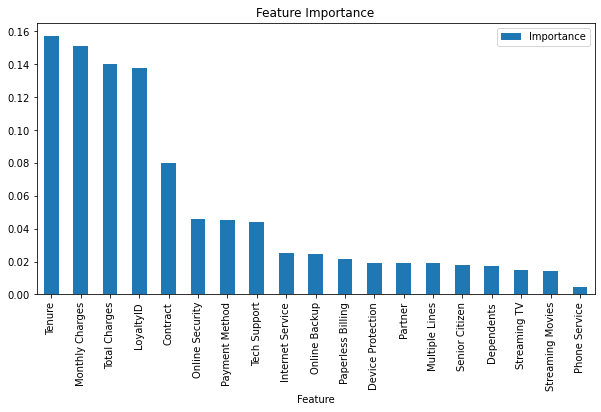

In [18]:
feature_importance.plot(
    x="Feature",
    y="Importance",
    kind="bar",
    figsize=(10,5)
)

plt.title("Feature Importance")
plt.show()

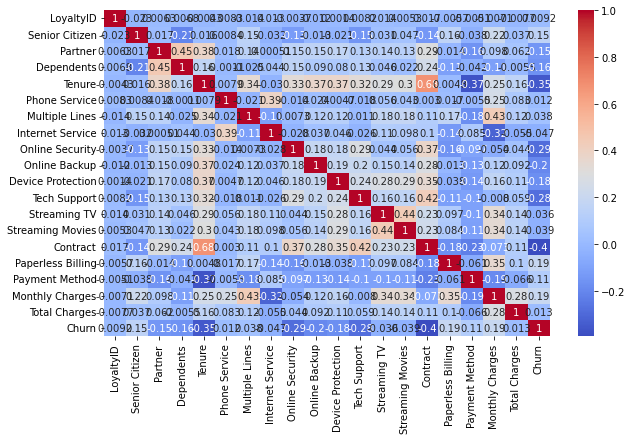

In [19]:
# Correlation Matrix
corr = df_encoded.corr()

plt.figure(figsize=(10,6))
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.show()

In [20]:
corr.loc["Tenure", "Total Charges"]

0.1555394754661739

In [21]:
corr.loc["Monthly Charges", "Churn"]

0.192858218470079

In [22]:
corr.loc["Tenure", "Churn"]

-0.3540493589532504

In [23]:
# Chi-Square Test
from sklearn.feature_selection import chi2

X = df_encoded.drop(target, axis=1)
y = df_encoded[target]

chi_scores = chi2(X, y)

chi_results = pd.DataFrame({
    "Feature": X.columns,
    "Chi2 Score": chi_scores[0]
}).sort_values(by="Chi2 Score", ascending=False)

chi_results

,Feature,Chi2 Score
0,LoyaltyID,74050.957601
4,Tenure,16377.328093
17,Monthly Charges,3653.074681
18,Total Charges,1273.755785
14,Contract,1111.759054
8,Online Security,550.437364
11,Tech Support,522.438934
9,Online Backup,229.441123
10,Device Protection,190.688004
1,Senior Citizen,133.482766


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [ ]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression()

model.fit(X_train, y_train)

In [ ]:
y_pred = model.predict(X_test)

In [ ]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("Accuracy:", accuracy_score(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

In [ ]:
# Example customer
new_customer = [[10, 65, 1, 0, 1]]

prediction = model.predict(new_customer)

if prediction[0] == 1:
    print("Customer is likely to churn")
else:
    print("Customer is NOT likely to churn")